# 01 – Exploratory Data Analysis

This notebook explores the EmoPairCompete dataset: distributions of biosignal features
and questionnaire responses, correlations, and per-phase comparisons.

In [13]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob

sns.set_theme(style='whitegrid')
%matplotlib inline

In [14]:
# Load all CSV files — column names are read directly from each file's header
data_dir = Path('../data/raw/data')

csv_files = glob.glob(str(data_dir / '**/*.csv'), recursive=True)
dfs = {}
for f in sorted(csv_files):
    key = Path(f).stem
    dfs[key] = pd.read_csv(f, index_col=0)
    print(f"{Path(f).relative_to(data_dir)}  →  {dfs[key].shape}")

# Main feature dataset
df = dfs['HR_data']
print(f'\nMain dataset: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

HR_data.csv  →  (312, 67)
dataset/D1_1/ID_1/round_1/phase1/BVP.csv  →  (28624, 2)
dataset/D1_1/ID_1/round_1/phase1/EDA.csv  →  (1789, 2)
dataset/D1_1/ID_1/round_1/phase1/HR.csv  →  (448, 2)
dataset/D1_1/ID_1/round_1/phase1/TEMP.csv  →  (1789, 2)
dataset/D1_1/ID_1/round_1/phase1/response.csv  →  (1, 15)
dataset/D1_1/ID_1/round_1/phase2/BVP.csv  →  (25081, 2)
dataset/D1_1/ID_1/round_1/phase2/EDA.csv  →  (1567, 2)
dataset/D1_1/ID_1/round_1/phase2/HR.csv  →  (392, 2)
dataset/D1_1/ID_1/round_1/phase2/TEMP.csv  →  (1567, 2)
dataset/D1_1/ID_1/round_1/phase2/response.csv  →  (1, 16)
dataset/D1_1/ID_1/round_1/phase3/BVP.csv  →  (23691, 2)
dataset/D1_1/ID_1/round_1/phase3/EDA.csv  →  (1480, 2)
dataset/D1_1/ID_1/round_1/phase3/HR.csv  →  (370, 2)
dataset/D1_1/ID_1/round_1/phase3/TEMP.csv  →  (1480, 2)
dataset/D1_1/ID_1/round_1/phase3/response.csv  →  (1, 15)
dataset/D1_1/ID_1/round_2/phase1/BVP.csv  →  (19565, 2)
dataset/D1_1/ID_1/round_2/phase1/EDA.csv  →  (1223, 2)
dataset/D1_1/ID_1/round_2/pha

,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
0,78.663878,76.70,7.480043,67.25,92.48,23048.450,-1.091448,0.369955,-0.7300,0.9775,...,1.0,1.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0
1,76.540732,76.61,2.584756,69.82,82.33,23959.920,-0.245338,0.338732,-0.3600,0.1900,...,2.0,1.0,3.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0
2,78.173563,77.92,2.681255,72.22,82.80,20324.605,-0.615922,-0.233047,-0.6300,0.3575,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
3,83.073688,83.88,7.363598,69.42,96.12,24924.300,-0.866610,-0.046021,-0.4650,0.6500,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
4,72.281250,72.91,3.193762,64.95,79.98,23052.100,0.200401,-0.560948,-0.3725,0.3375,...,3.0,1.0,3.0,2.0,3.0,3.0,4.0,2.0,4.0,4.0


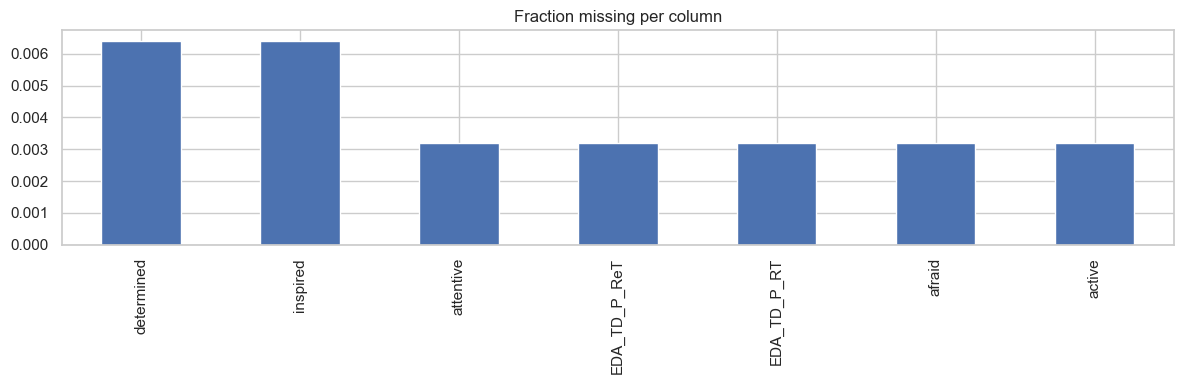

In [15]:
# Missing value summary
missing = df.isnull().mean().sort_values(ascending=False)
missing[missing > 0].plot(kind='bar', figsize=(12, 4), title='Fraction missing per column')
plt.tight_layout()
plt.savefig('../results/figures/missing_values.png', dpi=150)
plt.show()

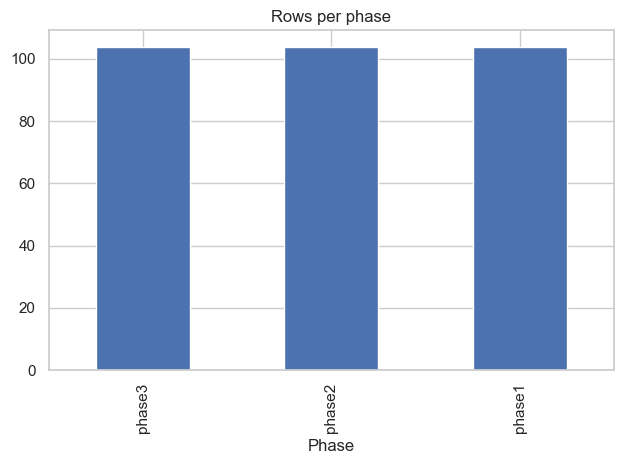

In [16]:
# Phase distribution
df['Phase'].value_counts().plot(kind='bar', title='Rows per phase')
plt.tight_layout()
plt.show()

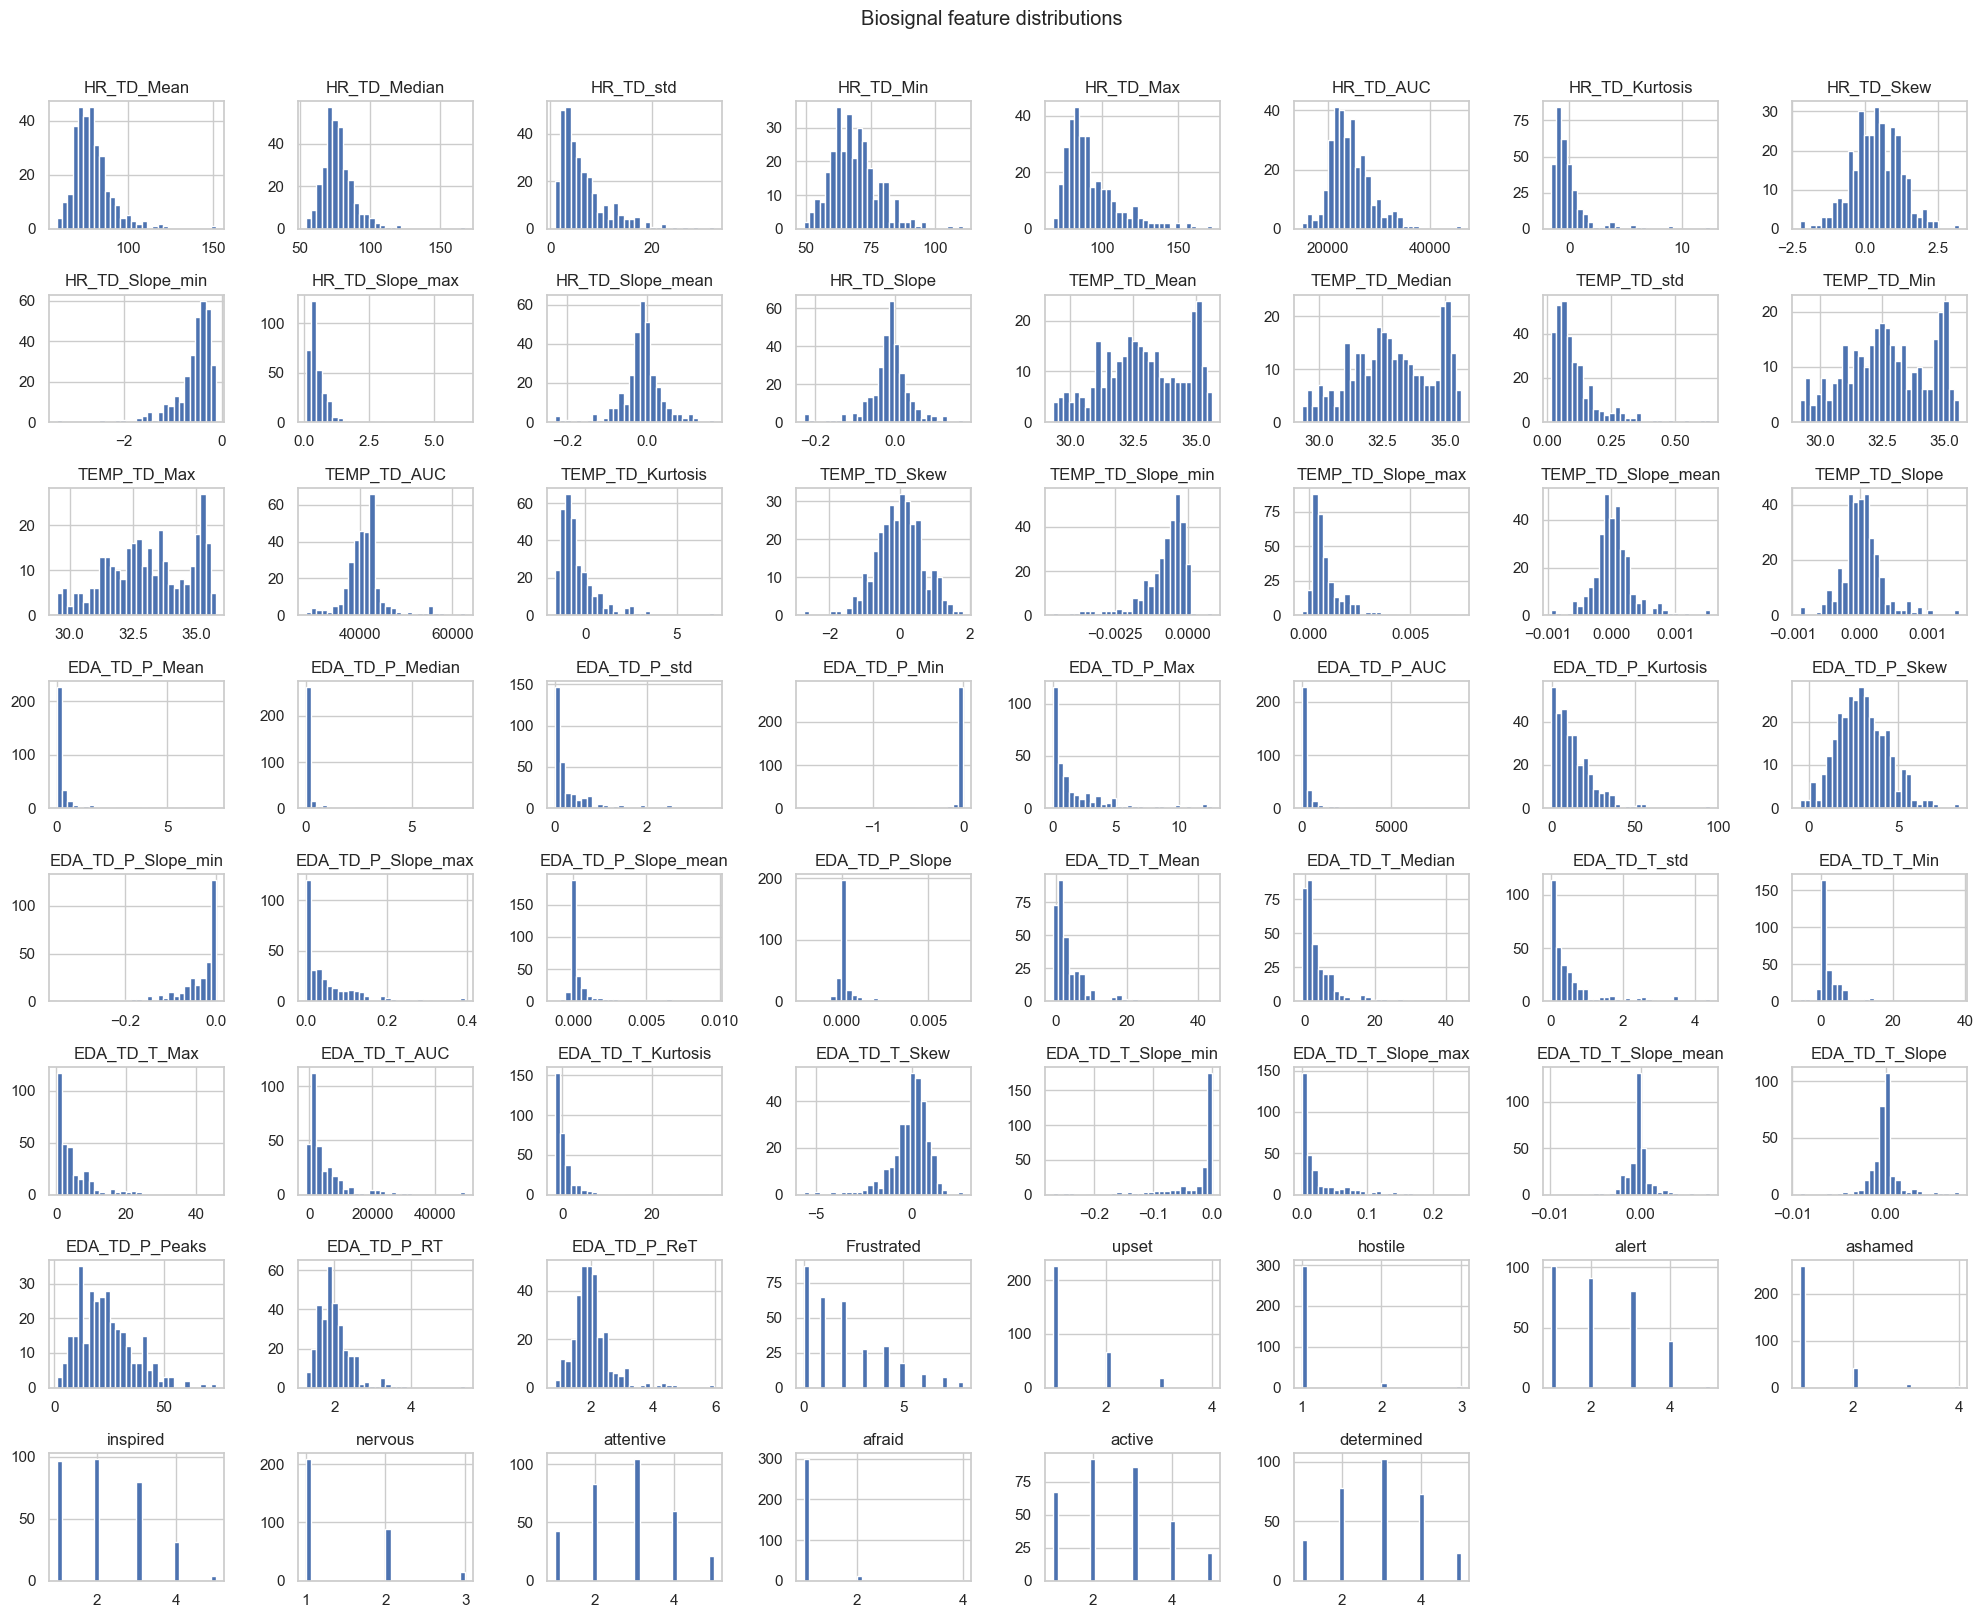

In [17]:
# Biosignal feature distributions — numeric columns, excluding metadata
meta_cols = ['Round', 'Phase', 'Individual', 'Puzzler', 'Cohort']
numeric_cols = df.select_dtypes(include='number').columns.tolist()
biosignal_cols = [c for c in numeric_cols if c not in meta_cols]

df[biosignal_cols].hist(bins=30, figsize=(20, 16))
plt.suptitle('Biosignal feature distributions', y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/biosignal_distributions.png', dpi=150)
plt.show()

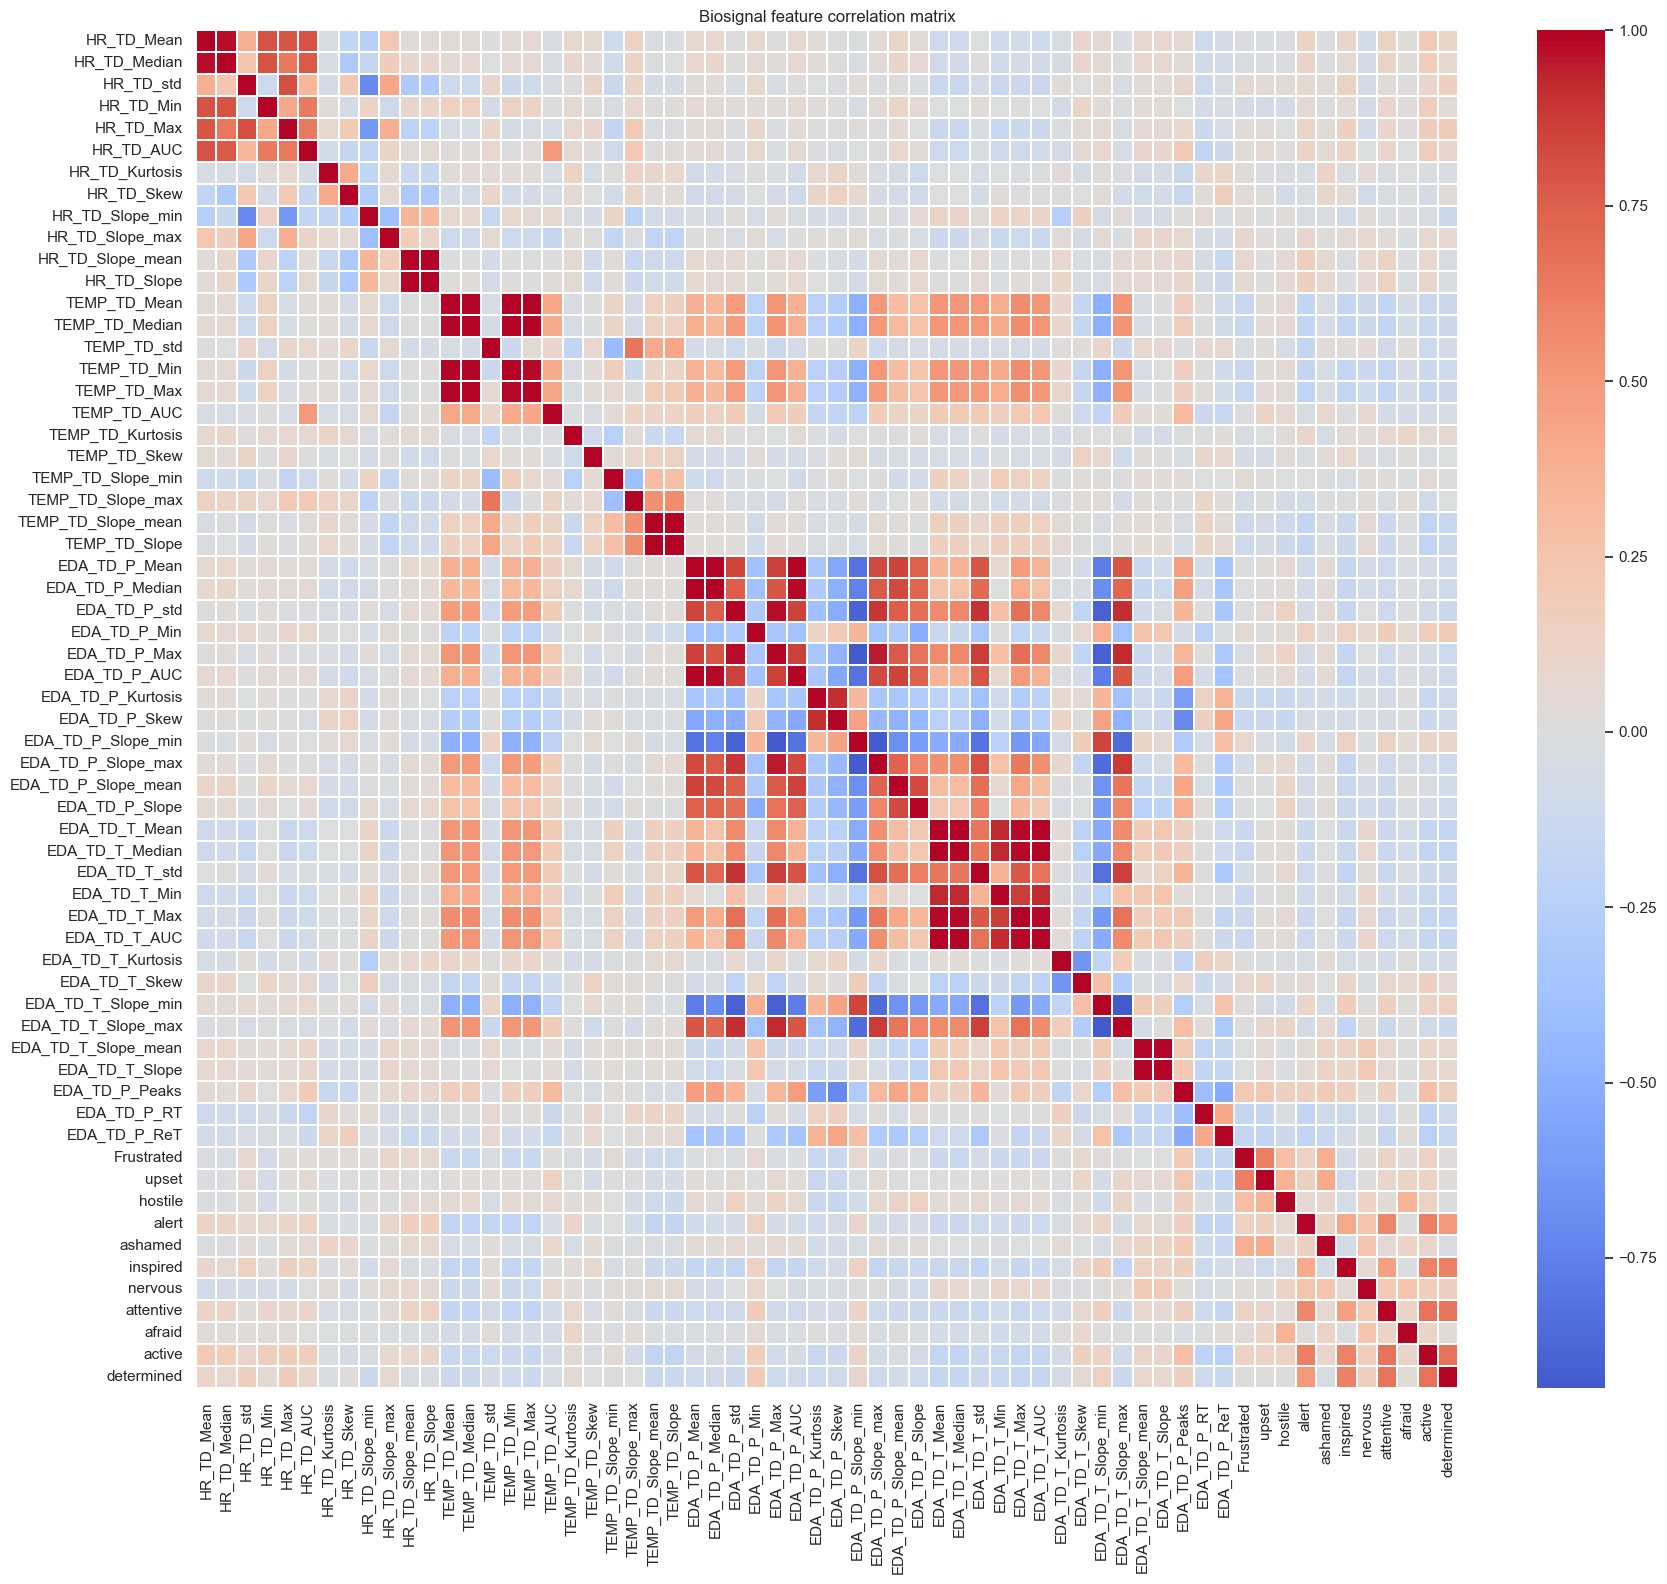

In [18]:
# Correlation heatmap — all numeric biosignal columns
corr = df[biosignal_cols].corr()
plt.figure(figsize=(18, 16))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Biosignal feature correlation matrix')
plt.tight_layout()
plt.savefig('../results/figures/biosignal_correlation.png', dpi=150)
plt.show()